<a href="https://www.kaggle.com/code/lalit7881/stroke-risk-dataset-eda?scriptVersionId=310649861" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ranaghulamnabi/stroke-risk-dataset/healthcare-dataset-stroke-data.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ranaghulamnabi/stroke-risk-dataset/healthcare-dataset-stroke-data.csv")

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [7]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [10]:
df.shape

(5110, 12)

In [11]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [12]:
df.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

## EDA

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 e

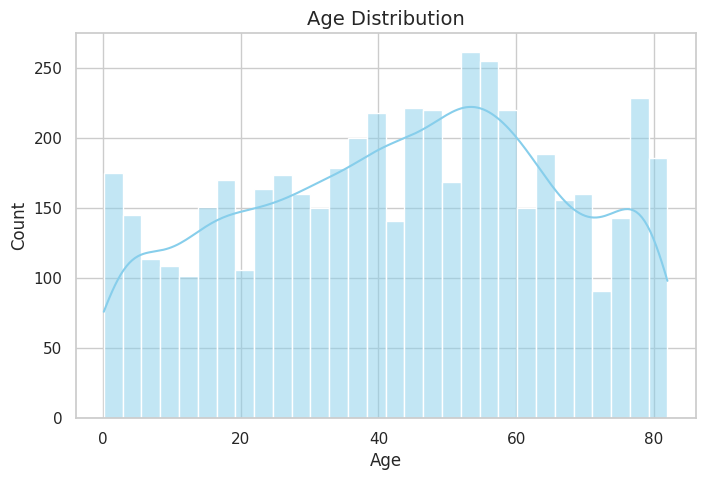

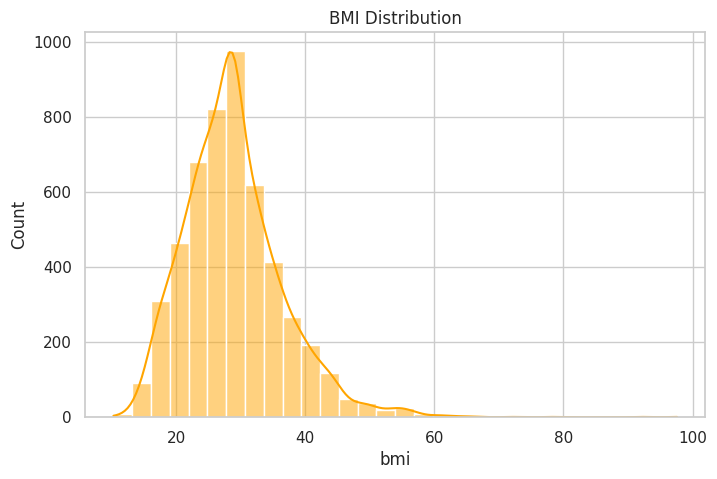

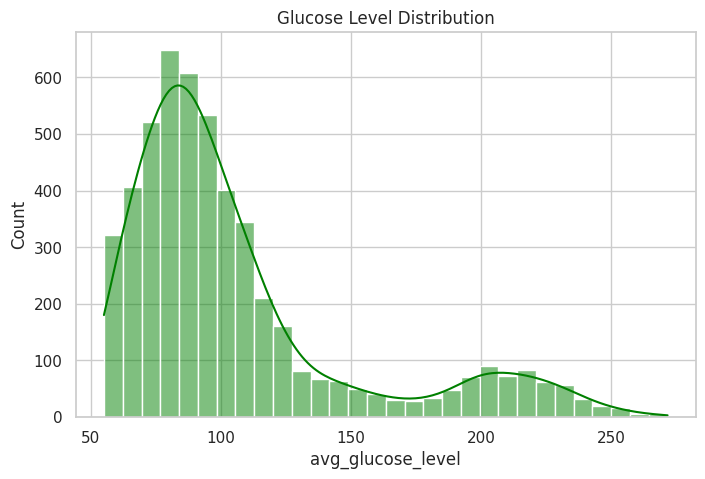

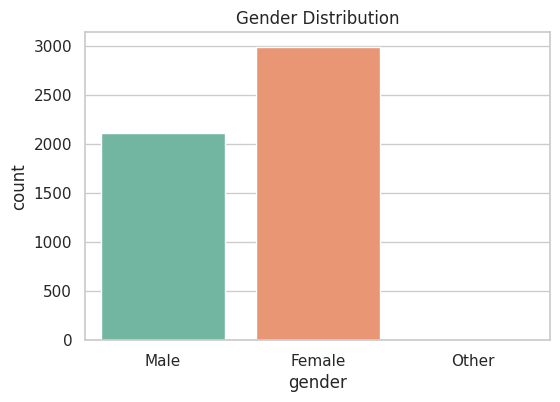

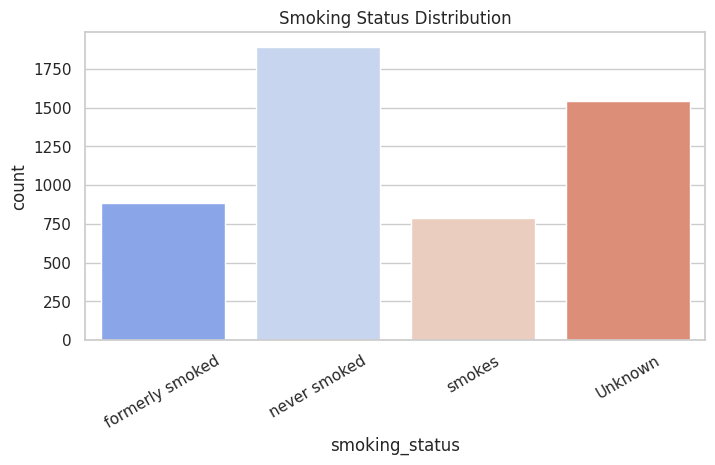

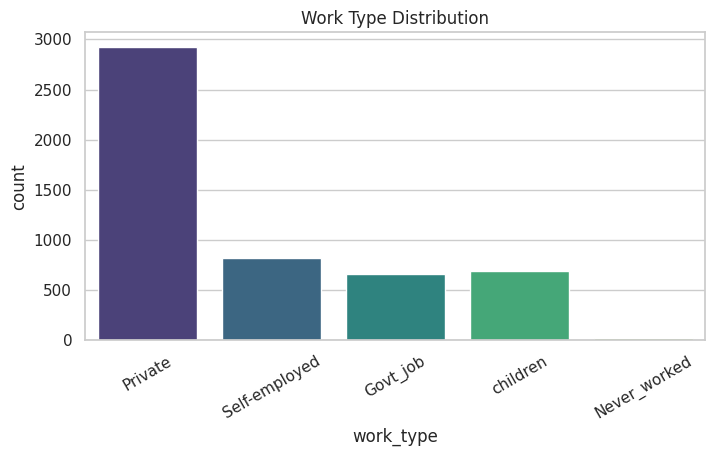

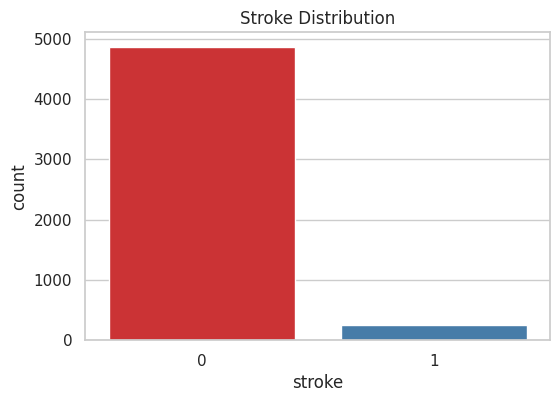

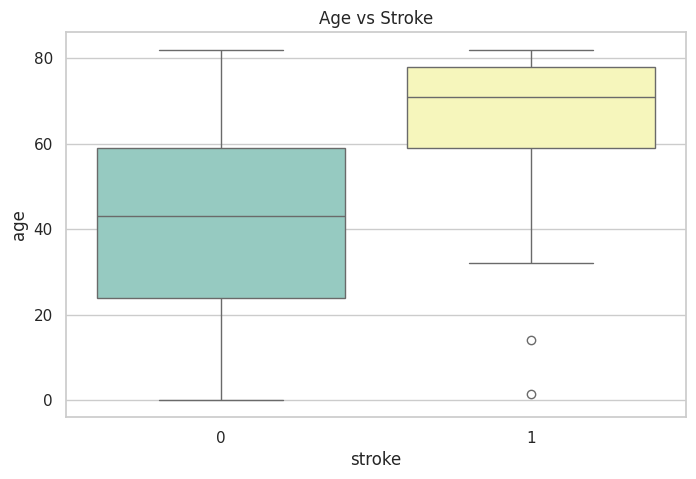

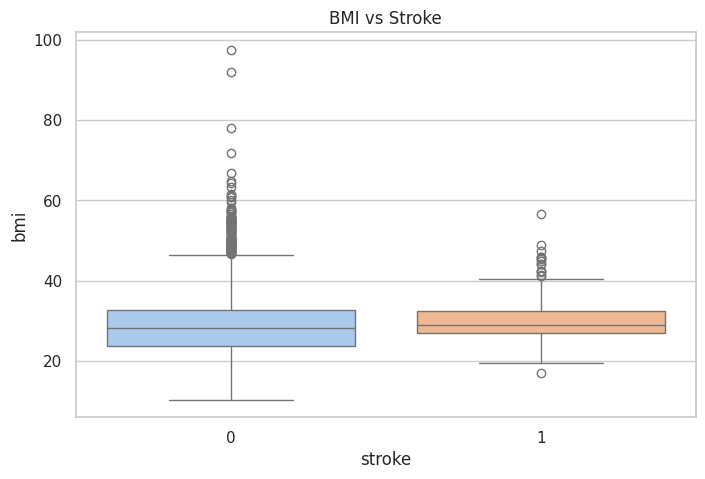

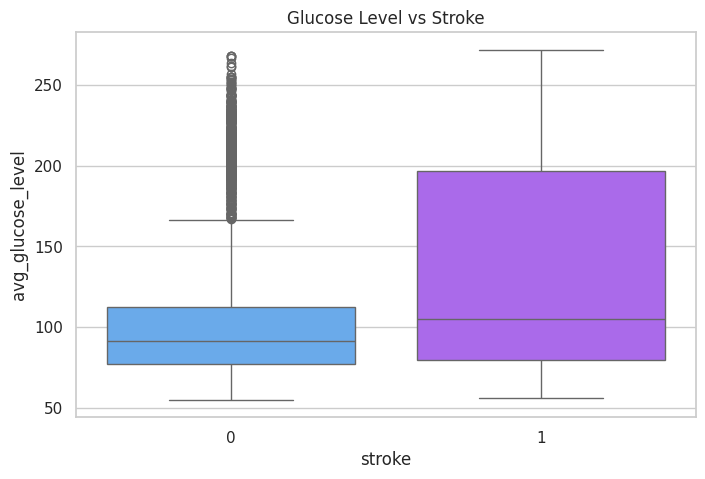

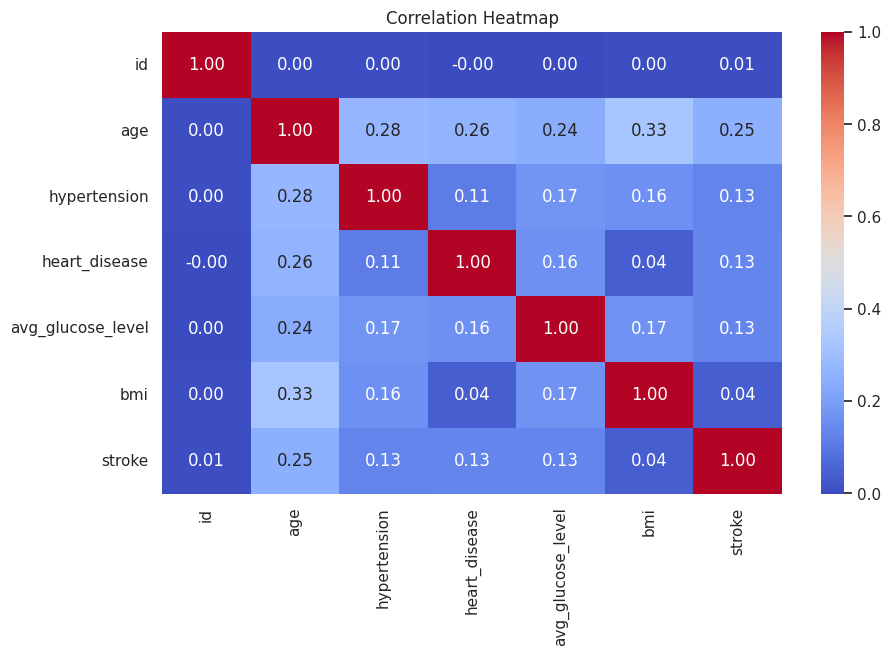

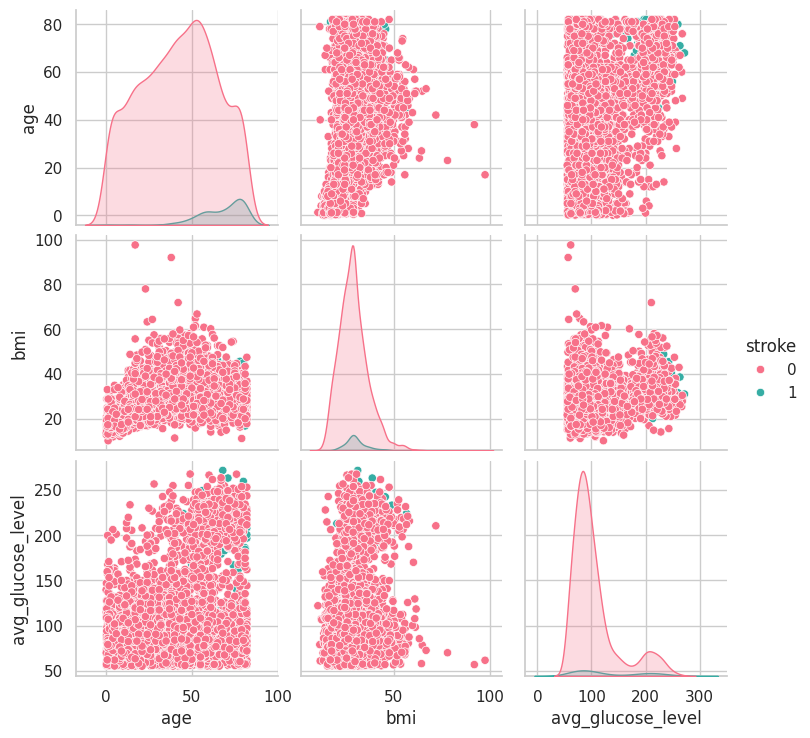

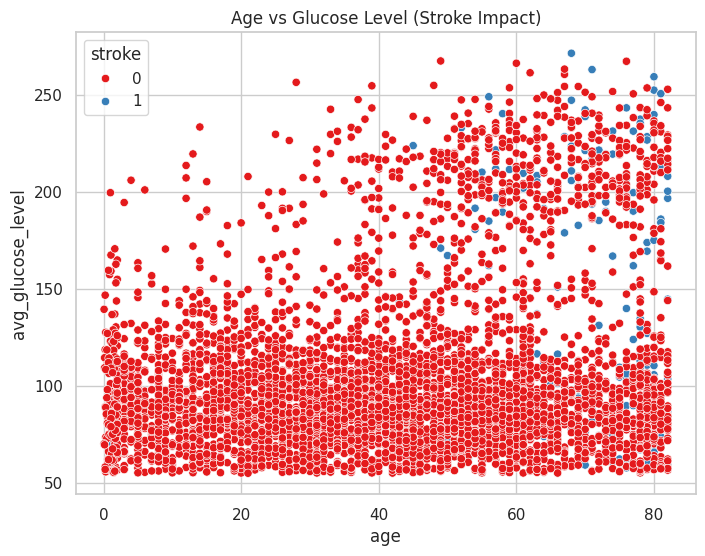

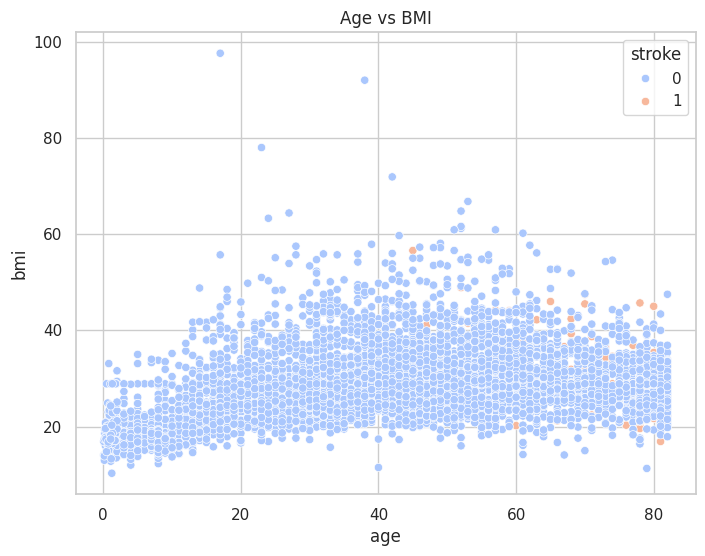

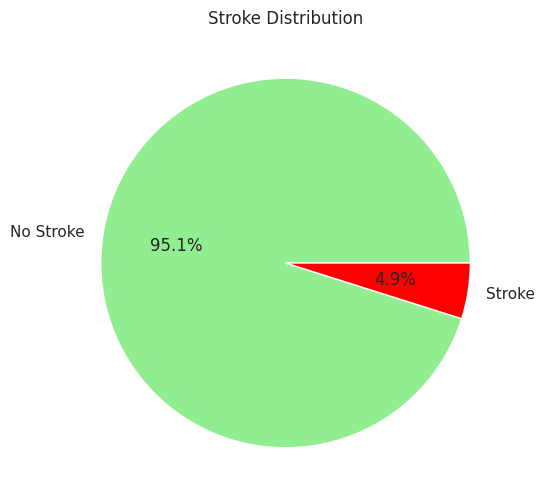

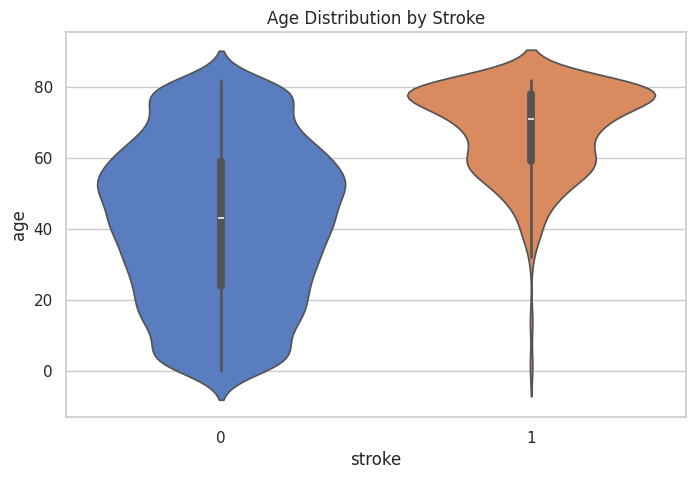

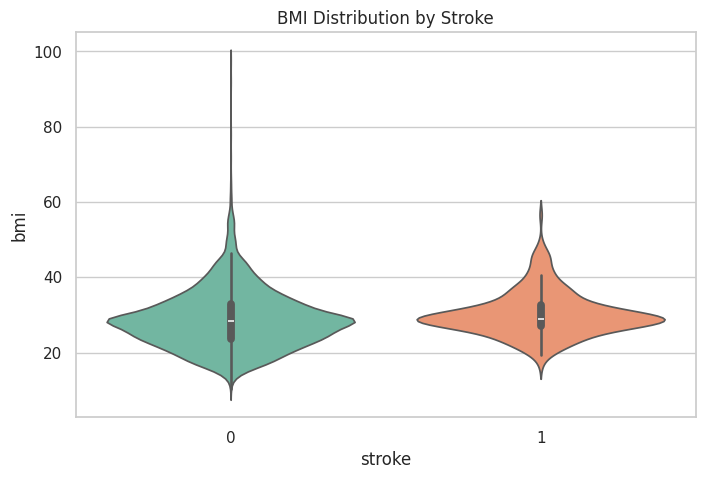

In [13]:

# Set style
plt.style.use('default')
sns.set_theme(style="whitegrid")

# ==============================
# 3. Basic Info
# ==============================
print(df.head())
print(df.info())
print(df.describe())

# ==============================
# 4. Handle Missing Values
# ==============================
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

# ==============================
# 5. Univariate Analysis
# ==============================

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, color='skyblue', kde=True)
plt.title("Age Distribution", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# BMI Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=30, color='orange', kde=True)
plt.title("BMI Distribution")
plt.show()

# Glucose Level Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['avg_glucose_level'], bins=30, color='green', kde=True)
plt.title("Glucose Level Distribution")
plt.show()

# ==============================
# 6. Categorical Count Plots
# ==============================

# Gender Count
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df, palette='Set2')
plt.title("Gender Distribution")
plt.show()

# Smoking Status
plt.figure(figsize=(8,4))
sns.countplot(x='smoking_status', data=df, palette='coolwarm')
plt.title("Smoking Status Distribution")
plt.xticks(rotation=30)
plt.show()

# Work Type
plt.figure(figsize=(8,4))
sns.countplot(x='work_type', data=df, palette='viridis')
plt.title("Work Type Distribution")
plt.xticks(rotation=30)
plt.show()

# Stroke Count
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df, palette='Set1')
plt.title("Stroke Distribution")
plt.show()

# ==============================
# 7. Bivariate Analysis
# ==============================

# Age vs Stroke
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='age', data=df, palette='Set3')
plt.title("Age vs Stroke")
plt.show()

# BMI vs Stroke
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='bmi', data=df, palette='pastel')
plt.title("BMI vs Stroke")
plt.show()

# Glucose vs Stroke
plt.figure(figsize=(8,5))
sns.boxplot(x='stroke', y='avg_glucose_level', data=df, palette='cool')
plt.title("Glucose Level vs Stroke")
plt.show()

# ==============================
# 8. Correlation Heatmap
# ==============================

plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 9. Pairplot (Important Features)
# ==============================

sns.pairplot(df[['age', 'bmi', 'avg_glucose_level', 'stroke']],
             hue='stroke',
             palette='husl')
plt.show()

# ==============================
# 10. Advanced Visualization
# ==============================

# Age vs Glucose colored by Stroke
plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='avg_glucose_level',
                hue='stroke',
                palette='Set1',
                data=df)
plt.title("Age vs Glucose Level (Stroke Impact)")
plt.show()

# BMI vs Age
plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='bmi',
                hue='stroke',
                palette='coolwarm',
                data=df)
plt.title("Age vs BMI")
plt.show()

# ==============================
# 11. Pie Chart (Stroke)
# ==============================

stroke_counts = df['stroke'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(stroke_counts,
        labels=['No Stroke', 'Stroke'],
        autopct='%1.1f%%',
        colors=['lightgreen', 'red'])
plt.title("Stroke Distribution")
plt.show()

# ==============================
# 12. Violin Plot
# ==============================

plt.figure(figsize=(8,5))
sns.violinplot(x='stroke', y='age', data=df, palette='muted')
plt.title("Age Distribution by Stroke")
plt.show()

plt.figure(figsize=(8,5))
sns.violinplot(x='stroke', y='bmi', data=df, palette='Set2')
plt.title("BMI Distribution by Stroke")
plt.show()

## Feture engineering


Logistic Regression Accuracy: 0.9521

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022


Decision Tree Accuracy: 0.9090

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.17      0.22      0.19        50

    accuracy                           0.91      1022
   macro avg       0.56      0.58      0.57      1022
weighted avg       0.92      0.91      0.91      1022


Random Forest Accuracy: 0.9462

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1   

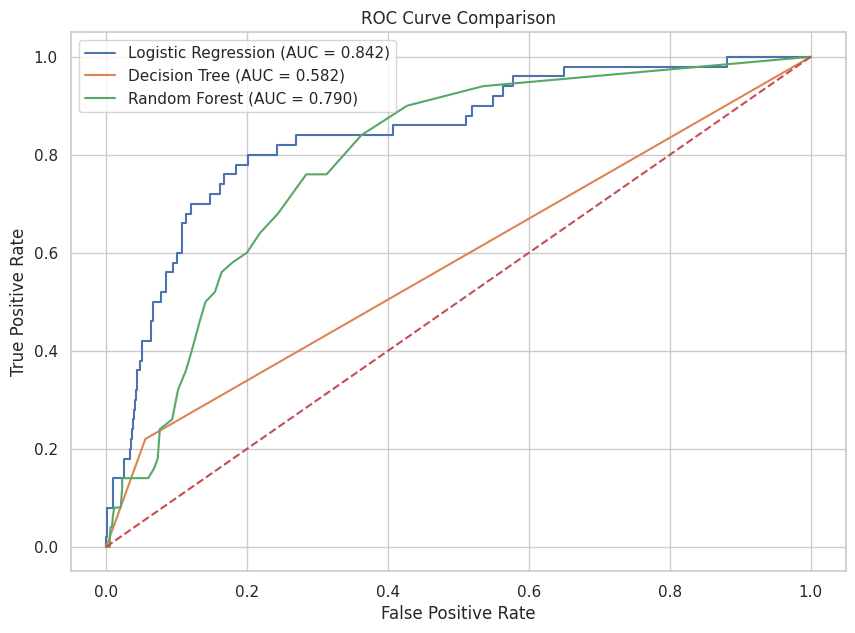

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

# ==============================
# 3. Basic Preprocessing
# ==============================

# Fill missing values
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

# Drop ID (not useful)
df = df.drop('id', axis=1)

# ==============================
# 4. Define Features & Target
# ==============================
X = df.drop('stroke', axis=1)
y = df['stroke']

# ==============================
# 5. Train-Test Split (NO LEAKAGE)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 6. Column Segregation
# ==============================
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# ==============================
# 7. Preprocessing Pipeline
# ==============================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# ==============================
# 8. Models Dictionary
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# ==============================
# 9. Training + Evaluation
# ==============================
plt.figure(figsize=(10,7))

for name, model in models.items():
    
    # Create Pipeline (NO LEAKAGE)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    
    # Classification Report
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# ==============================
# 10. Plot ROC Curve
# ==============================
plt.plot([0,1], [0,1], linestyle='--')  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!